In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.multioutput import MultiOutputRegressor
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

In [27]:
# 한글 표시
plt.rcParams['font.family'] = "Gulim"

### 데이터 로드

In [28]:
# 데이터 로드
df_merged = pd.read_csv('df_merged.csv')
y_targets = pd.read_csv('y_targets.csv')

# 기본 정보
months = df_merged['month'].values
scenarios = df_merged['scenario'].values

### 특성 엔지니어링

In [29]:
# 특성 그룹 정의
environmental = ['CO2ppm', 'Temp', 'Humid', 'VPD']
physiological = ['Chl_a', 'Chl_b', 'TChl', 'Car', 'Chl_a_b', 'TCh-Car']
fluorescence = ['ABS-RC', 'Dio-RC', 'Tro-RC', 'Eto-RC', 'PI_abs', 'DF_abs', 'SFI_abs', 'Fv-Fm']

In [30]:
# 원본 특성
original_features = environmental + physiological + fluorescence
X_original = df_merged[original_features].copy()

In [31]:
# 엔지니어링된 특성
X_engineered = X_original.copy()

In [32]:
# 1. 천궁 생육 단계 (월별)
growth_map = {5: 1, 6: 2, 7: 3, 8: 4, 9: 5}
X_engineered['growth_stage'] = [growth_map[m] for m in months]
X_engineered['growth_stage_sq'] = X_engineered['growth_stage'] ** 2

In [33]:
# 2. 시나리오 원핫인코딩
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    X_engineered[f'is_{scenario}'] = (scenarios == scenario).astype(int)

In [34]:
# 3. 온도 스트레스 지표
X_engineered['temp_stress'] = np.abs(X_engineered['Temp'] - 22)
X_engineered['temp_optimal'] = 1 / (1 + X_engineered['temp_stress'])

In [35]:
# 4. VPD 스트레스
X_engineered['vpd_stress'] = np.where(X_engineered['VPD'] > 1.5, X_engineered['VPD'] - 1.5, 0)

In [36]:
# 5. CO2 효과
X_engineered['co2_effect'] = np.log1p(X_engineered['CO2ppm'] / 400)

In [37]:
# 6. 광합성 효율 지표
X_engineered['photosyn_efficiency'] = X_engineered['PI_abs'] * X_engineered['Fv-Fm']
X_engineered['energy_dissipation'] = X_engineered['Dio-RC'] / (X_engineered['ABS-RC'] + 1e-10)

In [38]:
# 7. 시나리오별 상호작용
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    X_engineered[f'temp_x_{scenario}'] = X_engineered['Temp'] * X_engineered[f'is_{scenario}']

In [39]:
print(f"원본 특성 수: {X_original.shape[1]}")
print(f"엔지니어링 후 특성 수: {X_engineered.shape[1]}")

원본 특성 수: 18
엔지니어링 후 특성 수: 32


### 평가 함수 정의

In [40]:
def calculate_metrics(y_true, y_pred):
    """종합 평가 메트릭 계산"""
    # numpy 배열로 변환하여 Series 오류 방지
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    # MAPE 계산
    mask = y_true != 0
    if np.sum(mask) > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = 0
    
    # R2
    r2 = r2_score(y_true, y_pred)
    
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2
    }

### 모델 정의 (최적화된 하이퍼파라미터)

In [41]:
models = {
    'LinearR': LinearRegression(),
    
    'Ridge': Ridge(alpha=1.0, random_state=42),
    
    'kNN': KNeighborsRegressor(
        n_neighbors=7,
        weights='distance',
        metric='minkowski',
        p=2
    ),
    
    'SVM': SVR(
        kernel='rbf',
        C=3.0,
        epsilon=0.05,
        gamma='scale'
    ),
    
    'DT': DecisionTreeRegressor(
        max_depth=15,
        min_samples_split=3,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42
    ),
    
    'RF': RandomForestRegressor(
        n_estimators=500,
        max_depth=20,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    ),
    
    'GB': GradientBoostingRegressor(
        n_estimators=300,
        max_depth=7,
        learning_rate=0.08,
        subsample=0.85,
        min_samples_split=3,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42
    ),
    
    'XGB': xgb.XGBRegressor(
        n_estimators=400,
        max_depth=9,
        learning_rate=0.04,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=1.0,
        min_child_weight=2,
        gamma=0.1,
        random_state=42,
        n_jobs=-1,
        tree_method='hist',
        verbose=0
    ),
    
    'LGBM': lgb.LGBMRegressor(
        n_estimators=400,
        max_depth=12,
        learning_rate=0.05,
        num_leaves=64,
        min_child_samples=5,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=0.5,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
        objective='regression',
        metric='mae'
    )
}

# 네이티브 다중출력 지원 모델
NATIVE_MULTIOUTPUT = ['RF', 'DT', 'kNN', 'Ridge', 'LinearR']

### 시나리오별 + 월별 통합 분석

In [42]:
# 결과 저장
results = {
    'scenario': {},
    'month': {},
    'cross_val': {}
}

In [43]:
# 5.1 시나리오별 분석
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    print(f"\n=== {scenario} 시나리오 ===")
    
    # 데이터 분리
    scenario_mask = scenarios == scenario
    X_scenario = X_engineered[scenario_mask]
    y_scenario = y_targets[scenario_mask]
    
    # 훈련/테스트 분리 (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scenario, y_scenario, test_size=0.2, random_state=42
    )
    
    # 스케일링
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 모델별 성능
    scenario_results = {}
    
    for model_name, base_model in models.items():
        model = base_model if model_name in NATIVE_MULTIOUTPUT else MultiOutputRegressor(base_model)
        
        try:
            # 학습
            model.fit(X_train_scaled, y_train)
            
            # 예측
            y_pred = model.predict(X_test_scaled)
            
            # 평가
            metrics = calculate_metrics(y_test, y_pred)
            scenario_results[model_name] = metrics
            
            print(f"  {model_name}: MAE={metrics['MAE']:.4f}, MAPE={metrics['MAPE']:.2f}%, R2={metrics['R2']:.4f}")
            
        except Exception as e:
            print(f"  {model_name}: 오류 발생 - {e}")
    
    results['scenario'][scenario] = scenario_results


=== SSP1 시나리오 ===
  LinearR: MAE=0.1385, MAPE=3.35%, R2=0.9536
  Ridge: MAE=0.1861, MAPE=5.84%, R2=0.9448
  kNN: MAE=0.0834, MAPE=1.99%, R2=0.9643
  SVM: MAE=0.1099, MAPE=3.70%, R2=0.9489
  DT: MAE=0.0741, MAPE=1.68%, R2=0.9573


  RF: MAE=0.0721, MAPE=1.67%, R2=0.9738
  GB: MAE=0.0796, MAPE=1.69%, R2=0.9657
  XGB: MAE=0.1198, MAPE=3.49%, R2=0.8690
  LGBM: MAE=0.0758, MAPE=1.54%, R2=0.9699

=== SSP3 시나리오 ===
  LinearR: MAE=0.1132, MAPE=3.08%, R2=0.9438
  Ridge: MAE=0.1674, MAPE=4.72%, R2=0.9029
  kNN: MAE=0.1167, MAPE=3.17%, R2=0.9378
  SVM: MAE=0.1891, MAPE=5.50%, R2=0.8844
  DT: MAE=0.0588, MAPE=1.35%, R2=0.9627
  RF: MAE=0.0624, MAPE=1.58%, R2=0.9698
  GB: MAE=0.0581, MAPE=1.29%, R2=0.9671
  XGB: MAE=0.0720, MAPE=2.77%, R2=0.9467
  LGBM: MAE=0.0556, MAPE=1.34%, R2=0.9679

=== SSP5 시나리오 ===
  LinearR: MAE=0.0770, MAPE=1.72%, R2=0.9463
  Ridge: MAE=0.2042, MAPE=6.03%, R2=0.8863
  kNN: MAE=0.1564, MAPE=5.40%, R2=0.9126
  SVM: MAE=0.2367, MAPE=8.95%, R2=0.8317
  DT: MAE=0.0470, MAPE=1.05%, R2=0.9409
  RF: MAE=0.0384, MAPE=0.90%, R2=0.9631
  GB: MAE=0.0366, MAPE=0.79%, R2=0.9577
  XGB: MAE=0.0647, MAPE=2.42%, R2=0.8829
  LGBM: MAE=0.0306, MAPE=0.69%, R2=0.9667


In [44]:
# 5.2 월별 분석
print("\n[월별 분석]")
for month in sorted(np.unique(months)):
    print(f"\n=== {month}월 ===")
    
    month_mask = months == month
    X_month = X_engineered[month_mask]
    y_month = y_targets[month_mask]
    
    if len(X_month) < 10:  # 데이터가 너무 적으면 스킵
        print(f"  데이터 부족 ({len(X_month)} samples)")
        continue
    
    # 훈련/테스트 분리
    X_train, X_test, y_train, y_test = train_test_split(
        X_month, y_month, test_size=0.2, random_state=42
    )
    
    # 스케일링
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 간단한 모델만 테스트
    month_results = {}
    for model_name in ['RF', 'GB', 'XGB']:
        base_model = models[model_name]
        model = base_model if model_name in NATIVE_MULTIOUTPUT else MultiOutputRegressor(base_model)
        
        try:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            metrics = calculate_metrics(y_test, y_pred)
            month_results[model_name] = metrics
            
            print(f"  {model_name}: MAE={metrics['MAE']:.4f}, MAPE={metrics['MAPE']:.2f}%")
            
        except Exception as e:
            print(f"  {model_name}: 오류 - {e}")
    
    results['month'][month] = month_results


[월별 분석]

=== 5월 ===


  RF: MAE=0.0427, MAPE=0.99%
  GB: MAE=0.0529, MAPE=1.24%
  XGB: MAE=0.0304, MAPE=0.70%

=== 6월 ===
  RF: MAE=0.0458, MAPE=0.87%
  GB: MAE=0.0502, MAPE=0.97%
  XGB: MAE=0.0609, MAPE=1.63%

=== 7월 ===
  RF: MAE=0.0797, MAPE=1.44%
  GB: MAE=0.0808, MAPE=1.46%
  XGB: MAE=0.0894, MAPE=2.77%

=== 8월 ===
  RF: MAE=0.0289, MAPE=0.86%
  GB: MAE=0.0307, MAPE=0.93%
  XGB: MAE=0.0428, MAPE=2.56%

=== 9월 ===
  RF: MAE=0.0662, MAPE=1.45%
  GB: MAE=0.0687, MAPE=1.53%
  XGB: MAE=0.0827, MAPE=3.76%


In [45]:
# 5.3 교차검증 (전체 데이터)
print("\n[교차검증 - 전체 데이터]")
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name in ['RF', 'GB', 'XGB', 'LGBM']:
    base_model = models[model_name]
    
    # 스케일링
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X_engineered)
    
    # 각 타겟별 교차검증
    cv_scores = []
    for target_idx in range(y_targets.shape[1]):
        scores = cross_val_score(
            base_model, X_scaled, y_targets.iloc[:, target_idx],
            cv=kf, scoring='neg_mean_absolute_error'
        )
        cv_scores.append(-scores.mean())
    
    avg_cv_mae = np.mean(cv_scores)
    results['cross_val'][model_name] = avg_cv_mae
    print(f"{model_name}: 평균 CV MAE = {avg_cv_mae:.4f}")


[교차검증 - 전체 데이터]
RF: 평균 CV MAE = 0.0593
GB: 평균 CV MAE = 0.0606
XGB: 평균 CV MAE = 0.0740
LGBM: 평균 CV MAE = 0.0610


### 특성 중요도 분석

In [46]:
feature_importance = {}

for scenario in ['SSP1', 'SSP3', 'SSP5']:
    scenario_mask = scenarios == scenario
    X_scenario = X_engineered[scenario_mask]
    y_scenario = y_targets[scenario_mask]
    
    # RandomForest로 특성 중요도 계산
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_scenario, y_scenario)
    
    # 평균 특성 중요도
    importance = np.mean([est.feature_importances_ for est in rf.estimators_], axis=0)
    feature_importance[scenario] = importance
    
    # 상위 5개 특성
    feature_names = X_engineered.columns
    top_indices = np.argsort(importance)[-5:][::-1]
    print(f"\n{scenario} Top 5 특성:")
    for idx in top_indices:
        print(f"  {feature_names[idx]:20s}: {importance[idx]:.4f}")


SSP1 Top 5 특성:
  growth_stage        : 0.5200
  growth_stage_sq     : 0.3935
  temp_stress         : 0.0123
  Chl_b               : 0.0074
  TChl                : 0.0069

SSP3 Top 5 특성:
  growth_stage_sq     : 0.4983
  growth_stage        : 0.4068
  Dio-RC              : 0.0089
  SFI_abs             : 0.0074
  Temp                : 0.0070

SSP5 Top 5 특성:
  Dio-RC              : 0.3208
  growth_stage        : 0.3173
  growth_stage_sq     : 0.2632
  Humid               : 0.0127
  Car                 : 0.0117


### 시각화

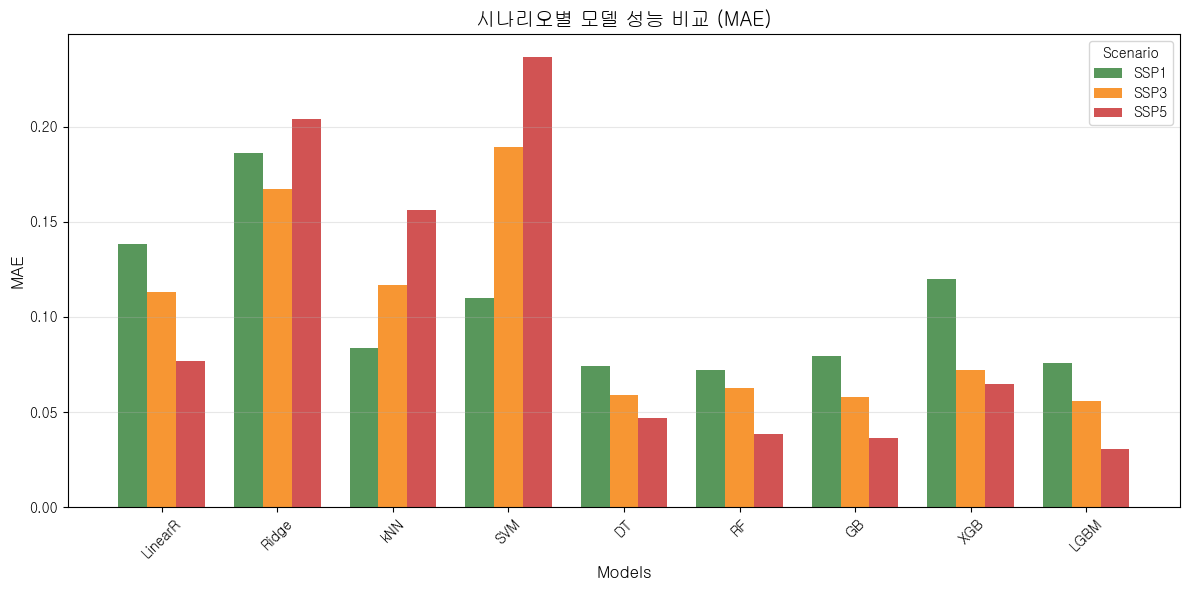

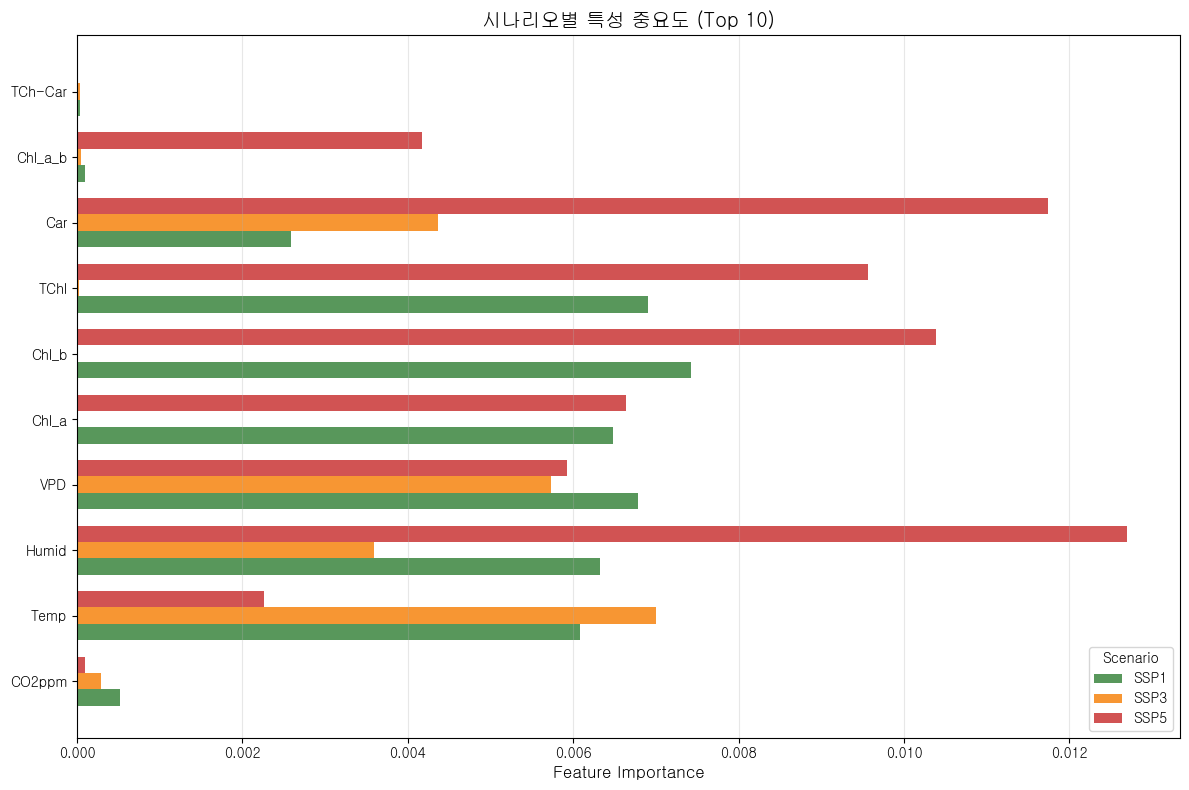

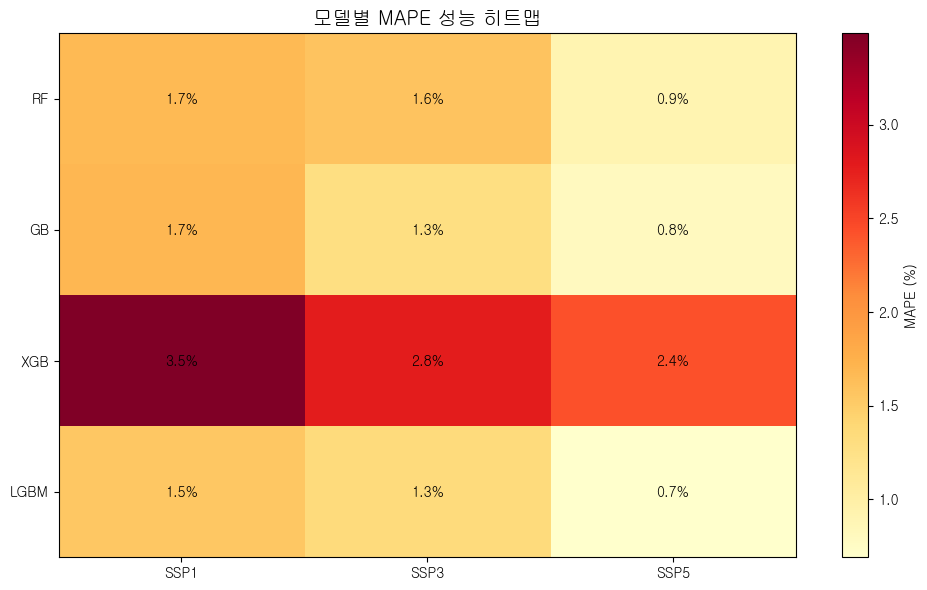

In [52]:
# 색상 설정
colors_ssp = {'SSP1': '#2E7D32', 'SSP3': '#F57C00', 'SSP5': '#C62828'}
model_colors = plt.cm.tab10(np.linspace(0, 0.9, len(models)))

# 그래프 1: 시나리오별 모델 성능 비교 (MAE)
plt.figure(figsize=(12, 6))
x = np.arange(len(models))
width = 0.25

for i, scenario in enumerate(['SSP1', 'SSP3', 'SSP5']):
    mae_values = [results['scenario'][scenario][model]['MAE'] 
                  for model in models.keys()]
    offset = (i - 1) * width
    plt.bar(x + offset, mae_values, width, 
           label=scenario, color=colors_ssp[scenario], alpha=0.8)

plt.xlabel('Models', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.title('시나리오별 모델 성능 비교 (MAE)', fontsize=14, fontweight='bold')
plt.xticks(x, models.keys(), rotation=45)
plt.legend(title='Scenario')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 그래프 2: 시나리오별 특성 중요도
plt.figure(figsize=(12, 8))
feature_names = X_engineered.columns[:10]  # 상위 10개만
n_features = len(feature_names)
y_pos = np.arange(n_features)
width = 0.25

for i, scenario in enumerate(['SSP1', 'SSP3', 'SSP5']):
    importance = feature_importance[scenario][:10]
    offset = (i - 1) * width
    plt.barh(y_pos + offset, importance, width, 
            label=scenario, color=colors_ssp[scenario], alpha=0.8)

plt.yticks(y_pos, feature_names)
plt.xlabel('Feature Importance', fontsize=12)
plt.title('시나리오별 특성 중요도 (Top 10)', fontsize=14, fontweight='bold')
plt.legend(title='Scenario', loc='lower right')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 그래프 3: MAPE 히트맵
plt.figure(figsize=(10, 6))
mape_matrix = []
for model in ['RF', 'GB', 'XGB', 'LGBM']:
    row = [results['scenario'][scenario][model]['MAPE'] 
           for scenario in ['SSP1', 'SSP3', 'SSP5']]
    mape_matrix.append(row)

im = plt.imshow(mape_matrix, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, label='MAPE (%)')
plt.xticks(range(3), ['SSP1', 'SSP3', 'SSP5'])
plt.yticks(range(4), ['RF', 'GB', 'XGB', 'LGBM'])
plt.title('모델별 MAPE 성능 히트맵', fontsize=14, fontweight='bold')

# 값 표시
for i in range(4):
    for j in range(3):
        text = plt.text(j, i, f'{mape_matrix[i][j]:.1f}%',
                       ha="center", va="center", color="black", fontsize=10)
plt.tight_layout()
plt.show()


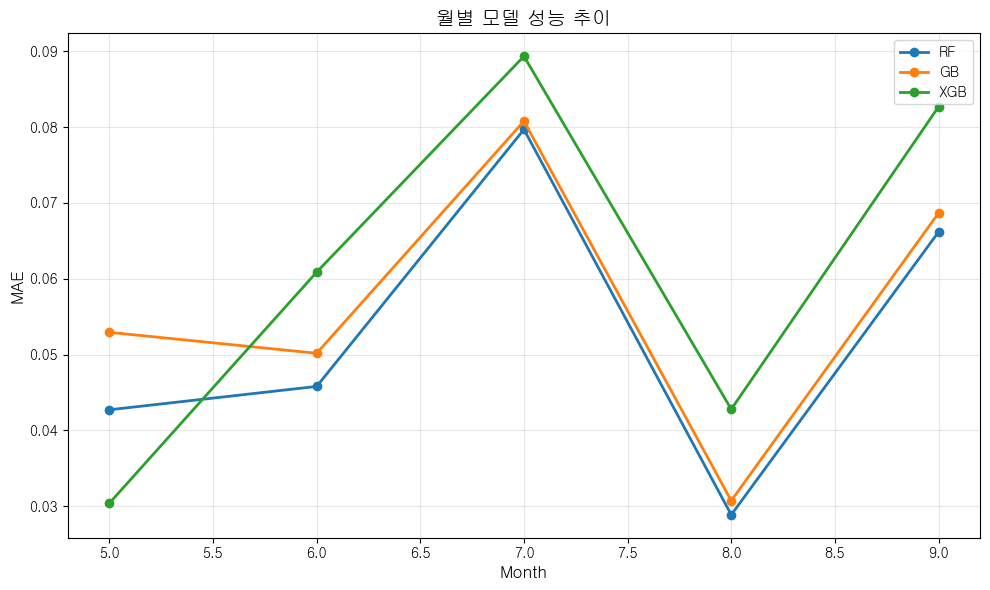

In [53]:
# 그래프 4: 월별 성능 추이
if results['month']:
    plt.figure(figsize=(10, 6))
    months_list = sorted(results['month'].keys())
    
    for model_name in ['RF', 'GB', 'XGB']:
        mae_values = []
        for month in months_list:
            if month in results['month'] and model_name in results['month'][month]:
                mae_values.append(results['month'][month][model_name]['MAE'])
            else:
                mae_values.append(np.nan)
        
        plt.plot(months_list, mae_values, marker='o', label=model_name, linewidth=2)
    
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('MAE', fontsize=12)
    plt.title('월별 모델 성능 추이', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

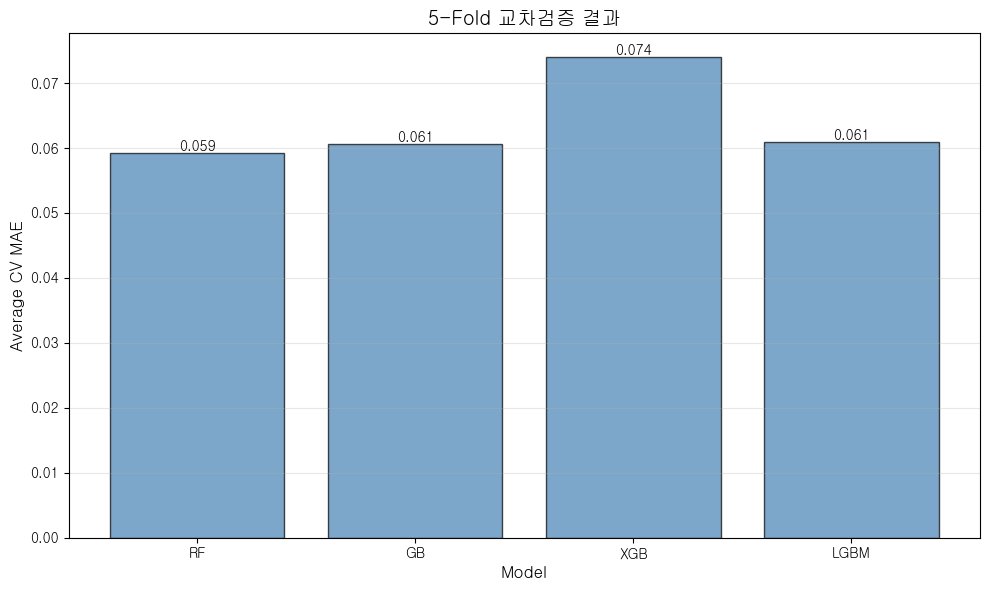

In [54]:
# 그래프 5: 교차검증 결과
plt.figure(figsize=(10, 6))
cv_models = list(results['cross_val'].keys())
cv_scores = list(results['cross_val'].values())

bars = plt.bar(cv_models, cv_scores, color='steelblue', alpha=0.7, edgecolor='black')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Average CV MAE', fontsize=12)
plt.title('5-Fold 교차검증 결과', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# 값 표시
for bar, score in zip(bars, cv_scores):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.3f}',
            ha='center', va='bottom')
plt.tight_layout()
plt.show()

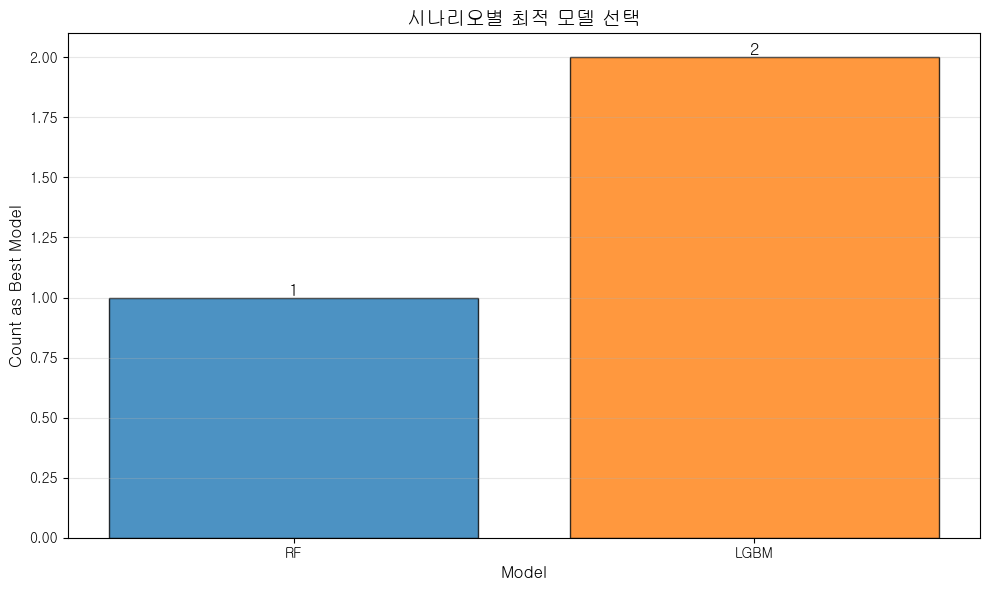

In [55]:
# 그래프 6: 최적 모델 선택 요약
plt.figure(figsize=(10, 6))
best_models = []
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    best = min(results['scenario'][scenario].items(), 
              key=lambda x: x[1]['MAE'])
    best_models.append(best[0])

from collections import Counter
model_counts = Counter(best_models)

bars = plt.bar(model_counts.keys(), model_counts.values(), 
              color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.8, edgecolor='black')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Count as Best Model', fontsize=12)
plt.title('시나리오별 최적 모델 선택', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# 값 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 최종결과

In [ ]:
print("\n[시나리오별 최고 성능 모델]")
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    best = min(results['scenario'][scenario].items(), 
              key=lambda x: x[1]['MAE'])
    print(f"{scenario}: {best[0]} (MAE={best[1]['MAE']:.4f}, MAPE={best[1]['MAPE']:.2f}%)")


[시나리오별 최고 성능 모델]
SSP1: RF (MAE=0.0721, MAPE=1.67%)
SSP3: LGBM (MAE=0.0556, MAPE=1.34%)
SSP5: LGBM (MAE=0.0306, MAPE=0.69%)


In [57]:
avg_performance = {}
for model in models.keys():
    mae_list = []
    for scenario in ['SSP1', 'SSP3', 'SSP5']:
        mae_list.append(results['scenario'][scenario][model]['MAE'])
    avg_performance[model] = np.mean(mae_list)

sorted_models = sorted(avg_performance.items(), key=lambda x: x[1])
for i, (model, mae) in enumerate(sorted_models[:3], 1):
    print(f"{i}. {model}: 평균 MAE = {mae:.4f}")

1. LGBM: 평균 MAE = 0.0540
2. RF: 평균 MAE = 0.0577
3. GB: 평균 MAE = 0.0581
